## Работа с библиотекой pandas в Python

In [176]:
import pandas as pd
%matplotlib inline
import seaborn as sns
from scipy.stats import norm

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [177]:
data = pd.read_csv('https://raw.githubusercontent.com/pileyan/Data/master/data/pima-indians-diabetes.csv')
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

__Задание 1.__

Как вы видите, в данных много пропусков (NaN). Посчитайте количество пропусков в каждом из столбцов.

In [178]:
# your code here
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Class                         0
dtype: int64

__Задание 2.__

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [179]:
# your code here
median = data.median()
mean = data.mean()
values = {
    "Pregnancies": median,
    "Glucose":median,
    "BloodPressure":median,	
    "SkinThickness":median,
    "Insulin":median,
    "BMI":mean,	
    "DiabetesPedigreeFunction":mean, 
    "Age":median}
data.fillna(data.median(), inplace = True)
data.head(10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1


__Задание 3.__

Вычислите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [180]:
# your code here
data.describe()
data.var()

Pregnancies                   11.354056
Glucose                      926.489244
BloodPressure                146.328741
SkinThickness                 77.285567
Insulin                     7462.033002
BMI                           47.268056
DiabetesPedigreeFunction       0.109779
Age                          138.303046
Class                          0.227483
dtype: float64

__Задание 4.__

У скольких женщин старше 50 лет обнаружен диабет?

In [181]:
# your code here
data[(data['Age']>50) & (data['Class']==1)].count()['Class']

np.int64(38)

__Задание 5.__

Найдите трех женщин с наибольшим числом беременностей.

In [182]:
# your code here
data.nlargest(3,['Pregnancies'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1
298,14,100.0,78.0,25.0,184.0,36.6,0.412,46,1


__Задание 6.__

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [183]:
# your code here
data[(data['Age']>=30) & (data['Age']<=40) & (data['Pregnancies']>=3)].count()['Class']

np.int64(142)

__Задание 7.__

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [184]:
# your code here
data[(data['BloodPressure']>=80) & (data['BloodPressure']<=89)].count()['Class']/data['Class'].count()*100

np.float64(18.880208333333336)

__Задание 8.__

Считается, что BMI >= 30 - это признак ожирения. 
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [185]:
# your code here
data[(data['BloodPressure']>data['BloodPressure'].mean()) & (data['BMI']>=30)].count()['Class']

np.int64(251)

__Задание 9.__

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет. 

In [186]:
# Glucose ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
if((data[data['Class']==0]['Glucose'].mean())>(data[data['Class']==1]['Glucose'].mean())):
  print("Больше у здоровых")
else:
  print("Больше у больных")

Больше у больных


In [187]:
# BloodPressure ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
if((data[data['Class']==0]['BloodPressure'].mean())>(data[data['Class']==1]['BloodPressure'].mean())):
  print("Больше у здоровых")
else:
  print("Больше у больных")

Больше у больных


In [188]:
# Insulin ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
if((data[data['Class']==0]['Insulin'].mean())>(data[data['Class']==1]['Insulin'].mean())):
  print("Больше у здоровых")
else:
  print("Больше у больных")

Больше у больных


__Задание 10.__

Постройте гистограммы для любых двух количественных признаков.

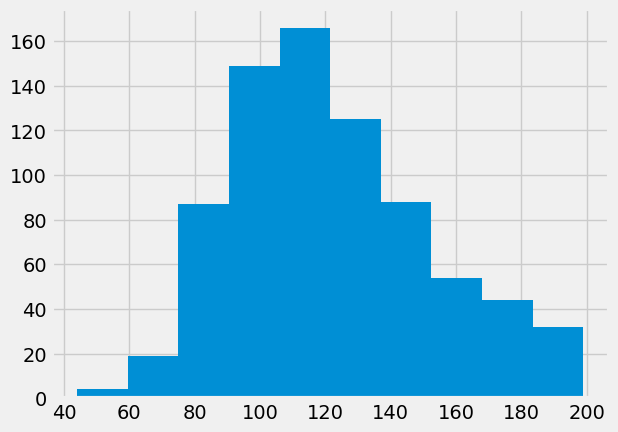

In [189]:
# your code here
import matplotlib.pyplot as plt
plt.hist(data[['Glucose']])
plt.show()

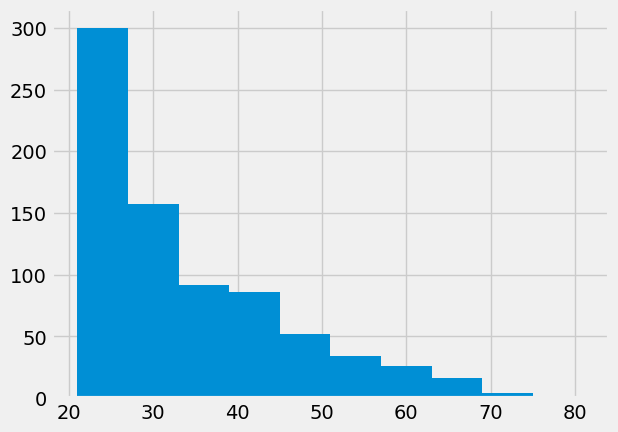

In [190]:
# your code here
plt.hist(data[['Age']])
plt.show()

__Задание 11.__

Постройте круговую диаграмму для признака __Class__.

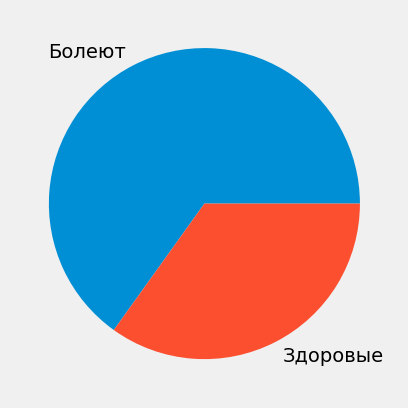

In [191]:
# your code here
labels = 'Болеют', 'Здоровые'
sizes = [data[data['Class']==0].count()['Class'], data[data['Class']==1].count()['Class']]
plt.pie(sizes, labels=labels)
plt.show()

__Задание 12.__

Постройте распределения для признаков __Age__ и __BloodPressure__ и сравните оба распределения с нормальным. 

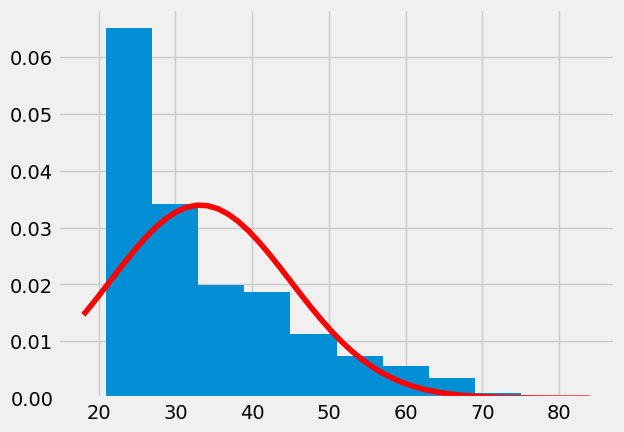

In [192]:
# your code here
import numpy as np

mu, std = norm.fit(data['Age'])

plt.hist(data['Age'], density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r')

plt.show()

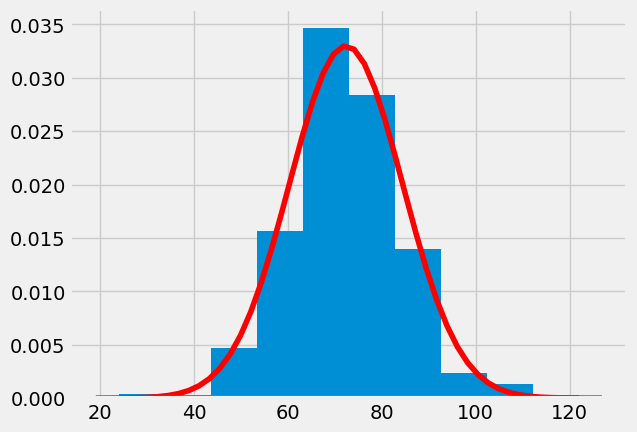

In [193]:
mu, std = norm.fit(data['BloodPressure'])

plt.hist(data['BloodPressure'], density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r')

plt.show()

__Задание 13.__

Постройте следующий график: среднее число больных диабетом в зависимости от числа беременностей.

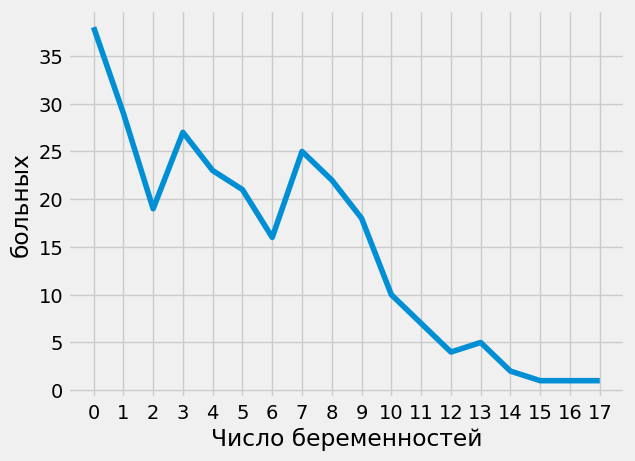

In [215]:
from matplotlib.ticker import MaxNLocator

plt.xlabel("Число беременностей")
plt.ylabel("больных")
plt.xticks(range(100))
# plt.figure().gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.plot(data[data['Class']==1].groupby('Pregnancies').size())

__Задание 14.__

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [195]:
data['wasPregnant'] = np.where(data['Pregnancies']>0, 1, 0)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,wasPregnant
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,0
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1,1


__Задание 15.__

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [203]:
print(data[(data['Class']==1) & (data['wasPregnant']==1)].count()['Class'] / data[data['wasPregnant']==1].count()['Class'] * 100)
print(data[(data['Class']==1) & (data['wasPregnant']==0)].count()['Class'] / data[data['wasPregnant']==0].count()['Class'] * 100)

35.0076103500761
34.234234234234236


__Задание 16.__

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__ 

Underweight = <18.5

Normal weight = 18.5–24.9 

Overweight = 25–29.9 

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [197]:
def f(row):
 if row['BMI'] < 18.5:
  val = 'Underweight'
 elif row['BMI'] <24.9:
  val = 'Normal weight'
 elif row['BMI'] < 29.9:
  val = 'Overweight'
 else :
  val = 'Obesity'
 return val

data['bodyType'] = data.apply (f, axis=1)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class,wasPregnant,bodyType
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1,Obesity
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1,Overweight
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1,Normal weight
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1,Overweight
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,0,Obesity
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0,1,Overweight
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,1,Obesity
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0,1,Obesity
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,1,Obesity
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1,1,Obesity


__Задание 17.__

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [198]:
n = data[(data['BloodPressure']>=80) & (data['BloodPressure']<=89) & (data['bodyType']=='Normal weight')].count()['Class']

data[(data['BloodPressure']>=80) & (data['BloodPressure']<=89) & (data['bodyType']=='Normal weight') & (data['Class']==1)].count()['Class']/n*100

np.float64(10.0)